# SSP spectroscopic predictions with `FaStar`
This notebook demonstrates how to use `FaStar`to generate spectroscopic predictions of simple stellar populations (SSP) models.

In [1]:
import time
import numpy as np

from matplotlib import pyplot as plt
from astropy.io.ascii import read as ascii_read
from astroquery.svo_fps import SvoFps
from IPython.display import display, Math

from fastar.integrated_ssp import IntegratedSynthesizer
from fastar.tools.utils import compute_ab_magnitudes, compute_linetrength

/home/imartin/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Basic functionalities
### 1. Calculating a SSP model

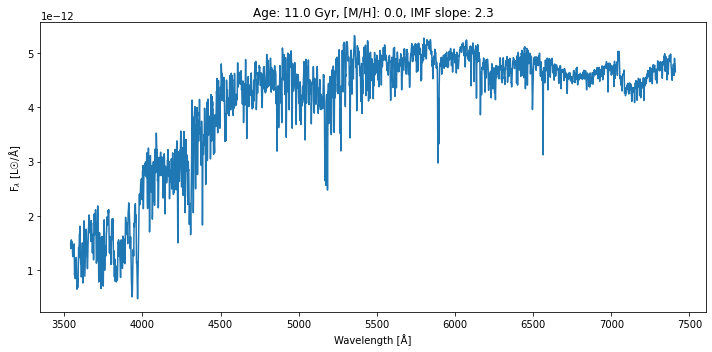

In [3]:
# The first thing is to decide which IMF you want to use.
# In this case a single power-law (Salpeter-like), but there 
# are plenty to chose from (or you can define your own functional
# form)
from fastar.imf.named_imf.single_power_law import single_power_law as unimodal

# Then load the SSP synthesizer with that IMF
ssp_spec = IntegratedSynthesizer(imf_function=unimodal)

# Now you can generate SSP models for any age, metallicity and IMF slope
age = 11.
met = 0.0
imf_slope = 2.3

# Synthesize SSP
wave, spec = ssp_spec.synthesize(age=age, met=met, imf_params={'alpha': imf_slope})

# Let's see how it looks
figsize=(10, 5)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(wave, spec)
ax.set_xlabel('Wavelength [Å]')
ax.set_ylabel('F$_\lambda$ [L☉/Å]')
ax.set_title(f"Age: {age} Gyr, [M/H]: {met}, IMF slope: {imf_slope}")
fig.tight_layout()
plt.show()

### 2. Get stellar masses and M/L ratios

In [4]:
# We can also calculate the stellar mass of the population,
# knowing that FaStar is normalized to one solar mass at birth.

fmass = ssp_spec.stellar_mass(age=age, met=met, imf_params={'alpha': imf_slope})

display(Math(f"\\text{{Mass in stars: }} {fmass:.3f}\\ M_\\odot"))

<IPython.core.display.Math object>

In [6]:
# FaStar can retrieve the mass-to-light ratio for any filter
# within the covered wavelength range

# Let's load for example the SDSS g-band filter
data = SvoFps.get_transmission_data('SLOAN/SDSS.g')
gtrans = np.interp(wave, data['Wavelength'], data['Transmission'], left=0, right=0)

# Once the filter is defined, we can get the ML
ml_ratio = ssp_spec.mass_to_light_ratio(age=age,met=met,imf_params={'alpha': imf_slope},filter_response=gtrans)

# FaStar retrieves 2 mass-to-light ratios.
#   ml_stars: mass in stars alive
#   ml_total: total mass (stars + gas + remnants)
ml_stars = ml_ratio['ml_stars']
ml_total = ml_ratio['ml_total']

display(Math(f"(\\mathrm{{M}}/\\mathrm{{L}})_{{g,\\ \\mathrm{{stars}}}}:\\ {ml_stars:.2f}\\ M_\\odot / L_\\odot"))
display(Math(f"(\\mathrm{{M}}/\\mathrm{{L}})_{{g,\\ \\mathrm{{total}}}}:\\ {ml_total:.2f}\\ M_\\odot / L_\\odot"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### 3. Colors and line-strengths

In [7]:
# Now get the SDSS r-band transmission
data = SvoFps.get_transmission_data('SLOAN/SDSS.r')
rtrans = np.interp(wave, data['Wavelength'], data['Transmission'], left=0, right=0)

# Calculate the magnitude in g and r
gmag = compute_ab_magnitudes(wave, spec, gtrans)
rmag = compute_ab_magnitudes(wave, spec, rtrans)

# Measure the color
gr_color = gmag - rmag

display(Math(f"(g-r):\\ {gr_color:.2f}"))

<IPython.core.display.Math object>

In [8]:
# Line-strength indices can also be measured
index_tab = ascii_read('../fastar/assets/indices.def')

# Let's measure Hbeta_0 for example
hbeta = compute_linetrength(wave, spec, 'Hbeta_o', index_tab)

display(Math(f"H_{{\\beta\\scriptscriptstyle O}}: {float(hbeta[0]):.2f}\\ \\text{{\\AA}}"))

<IPython.core.display.Math object>

### 4. Uncertainties in the SSP predictions

<function matplotlib.pyplot.show(close=None, block=None)>

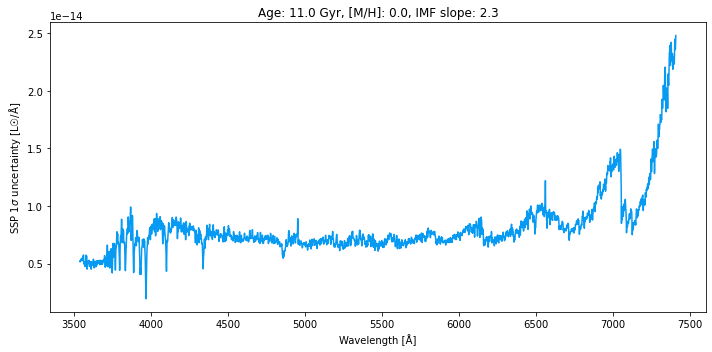

In [9]:
# Uncertainties on the SSP predictions can be estimated
# by propagating the typical error on the atmospheric
# parameters (logg, Teff and [Fe/H])

wave, std = ssp_spec.synthesize_nsim(
    age=age, met=met, imf_params={'alpha': imf_slope}
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(wave, std, label="Mean SSP Spectrum", color='xkcd:azure')

ax.set_xlabel('Wavelength [Å]')
ax.set_ylabel('SSP 1$\sigma$ uncertainty [L☉/Å]')
ax.set_title(f"Age: {age} Gyr, [M/H]: {met}, IMF slope: {imf_slope}")

fig.tight_layout()
plt.show


### 5. Model grid

A key feature of FaStar is that models can be continuously evaluated for any age, metallicity and IMF. However, certain applications might require using a constant grid of SSP models (in the same way standard SSP models are distributed). FaStar can also be used in this way. After defining and calculating the model grid, the SSP predictions are cached locally.

Moreover, the differentiable nature of FaStar allows optimizing the age, metallicity and IMF sampling depending on the application. For example, FaStar has a built-in age and metallicity sampling that ensures the same spectral variation in consecutive bins (e.g. coarse for old populations, fine steps for young SSPs). While this is roughly implemented in standard SSP models, with FaStar can be formally achieved. 

In [10]:
# Calculate a simple model grid
age_arr = [1,2,3]
met_arr = [-0.1,0,0.1]
wave, spec_grid = ssp_spec.load_precomputed_models(age_range=age_arr, met_range=met_arr)

# Alternatively, if no age and metallicity grids are provided, FaStar models will be calculated over the optimal grid described above
wave, spec_grid_fine = ssp_spec.load_precomputed_models()

# The optimally-sampled ages and metallicities are easily accessible
ages = ssp_spec.iso_ages
mets = ssp_spec.iso_ages

Calculating SSP predictions
Calculating SSP predictions


## Performance Test (50 SSPs)

In [11]:

init_time = time.time()
for _ in range(50):
    age = np.random.uniform(low=1, high=13.5)
    met = np.random.uniform(low=-2, high=0.3)
    imf_slope = np.random.uniform(low=1.3, high=2.5)
    _ = ssp_spec.synthesize(age=age, met=met, imf_params={'alpha': imf_slope})

dt1 = np.round(time.time() - init_time, 2)
dt2 = np.round(dt1 / 50.,3)
print(f"It takes {dt1}s to calculate 50 SSPs (i.e. {dt2}s per SSP)")


It takes 1.7s to calculate 50 SSPs (i.e. 0.034s per SSP)
